<a href="https://colab.research.google.com/github/SriSharanya-617/Movie_Sentiment_Project/blob/main/IMDB_gru.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from tensorflow.keras.datasets import imdb
import numpy as np
import pandas as pd

# Load dataset
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

# Combine train and test sets
reviews = np.concatenate([X_train, X_test])
labels = np.concatenate([y_train, y_test])

print("Total Reviews:", len(reviews))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total Reviews: 50000


In [2]:
total_reviews = len(reviews)
print("Number of Reviews:", total_reviews)

Number of Reviews: 50000


In [3]:
positive_reviews = np.sum(labels == 1)
print("Positive Reviews:", positive_reviews)

Positive Reviews: 25000


In [4]:
negative_reviews = np.sum(labels == 0)
print("Negative Reviews:", negative_reviews)

Negative Reviews: 25000


In [5]:
review_lengths = [len(review) for review in reviews]

avg_length = np.mean(review_lengths)
print("Average Review Length:", round(avg_length, 2))

Average Review Length: 234.76


In [6]:
longest_review = max(review_lengths)
print("Longest Review Length:", longest_review)

Longest Review Length: 2494


In [7]:
shortest_review = min(review_lengths)
print("Shortest Review Length:", shortest_review)

Shortest Review Length: 7


In [8]:
summary = pd.DataFrame({
    "Metric": [
        "Total Reviews",
        "Positive Reviews",
        "Negative Reviews",
        "Average Length",
        "Longest Review",
        "Shortest Review"
    ],
    "Value": [
        total_reviews,
        positive_reviews,
        negative_reviews,
        round(avg_length, 2),
        longest_review,
        shortest_review
    ]
})

print(summary)

             Metric     Value
0     Total Reviews  50000.00
1  Positive Reviews  25000.00
2  Negative Reviews  25000.00
3    Average Length    234.76
4    Longest Review   2494.00
5   Shortest Review      7.00


In [9]:
import numpy as np
import re
import string

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [10]:
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

word_index = imdb.get_word_index()

reverse_word_index = {
    value + 3: key
    for key, value in word_index.items()
}

reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
def decode_review(encoded_review):
    return ' '.join(
        [reverse_word_index.get(i, '?') for i in encoded_review]
    )

reviews_text = [decode_review(review) for review in X_train]

In [12]:
reviews_text = [review.lower() for review in reviews_text]

In [13]:
def remove_html(text):
    return re.sub(r'<.*?>', '', text)

reviews_text = [remove_html(review) for review in reviews_text]

In [14]:
def remove_punctuation(text):
    return text.translate(
        str.maketrans('', '', string.punctuation)
    )

reviews_text = [remove_punctuation(review)
                for review in reviews_text]

In [15]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words
             if word not in stop_words]
    return " ".join(words)

reviews_text = [remove_stopwords(review)
                for review in reviews_text]

In [16]:
tokenizer = Tokenizer(num_words=10000)

tokenizer.fit_on_texts(reviews_text)

sequences = tokenizer.texts_to_sequences(
    reviews_text
)

In [17]:
print(sequences[0])

[3, 419, 848, 1488, 1254, 10, 347, 4309, 11, 3792, 77, 154, 27, 718, 553, 369, 179, 73, 228, 276, 4377, 982, 335, 95, 56, 1884, 3, 1774, 4448, 357, 3, 20, 419, 14, 1119, 3, 405, 510, 9, 277, 208, 30, 2088, 5076, 369, 11, 3632, 46, 503, 43, 49, 1282, 3, 114, 6, 298, 17, 31, 39, 797, 154, 3601, 607, 419, 364, 291, 209, 906, 29, 272, 191, 1931, 97, 7281, 125, 3, 364, 369, 5353, 123, 21, 29, 125, 10, 1205, 178, 4310, 35, 5184, 81]


In [18]:
MAX_LEN = 250

X_train_pad = pad_sequences(
    sequences,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

In [19]:
reviews_test_text = [
    decode_review(review)
    for review in X_test
]

reviews_test_text = [
    remove_stopwords(
        remove_punctuation(
            remove_html(text.lower())
        )
    )
    for text in reviews_test_text
]

test_sequences = tokenizer.texts_to_sequences(
    reviews_test_text
)

X_test_pad = pad_sequences(
    test_sequences,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

In [20]:
print("Training Shape:", X_train_pad.shape)
print("Testing Shape:", X_test_pad.shape)

Training Shape: (25000, 250)
Testing Shape: (25000, 250)


In [21]:
X_train_pad.shape


X_test_pad.shape


(25000, 250)

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.optimizers import Adam

# Parameters
VOCAB_SIZE = 10000
MAX_LEN = 250

# Model
simple_rnn_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE,
              output_dim=128,
              input_length=MAX_LEN),

    SimpleRNN(64),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

# Compile
simple_rnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Model Summary
simple_rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
history_rnn = simple_rnn_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.4994 - loss: 0.6948 - val_accuracy: 0.4954 - val_loss: 0.6969
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.5349 - loss: 0.6803 - val_accuracy: 0.5032 - val_loss: 0.7003
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.5368 - loss: 0.6639 - val_accuracy: 0.5044 - val_loss: 0.7118
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.5368 - loss: 0.6553 - val_accuracy: 0.5032 - val_loss: 0.7007
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.5303 - loss: 0.6590 - val_accuracy: 0.4926 - val_loss: 0.7213


In [24]:
loss_rnn, accuracy_rnn = simple_rnn_model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print(f"Test Loss: {loss_rnn:.4f}")
print(f"Test Accuracy: {accuracy_rnn:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4990 - loss: 0.7139
Test Loss: 0.7139
Test Accuracy: 0.4990


In [25]:
sample_review = X_test_pad[0].reshape(1, -1)

prediction = simple_rnn_model.predict(sample_review)

if prediction > 0.5:
    print("Positive Review 😊")
else:
    print("Negative Review 😞")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step
Positive Review 😊


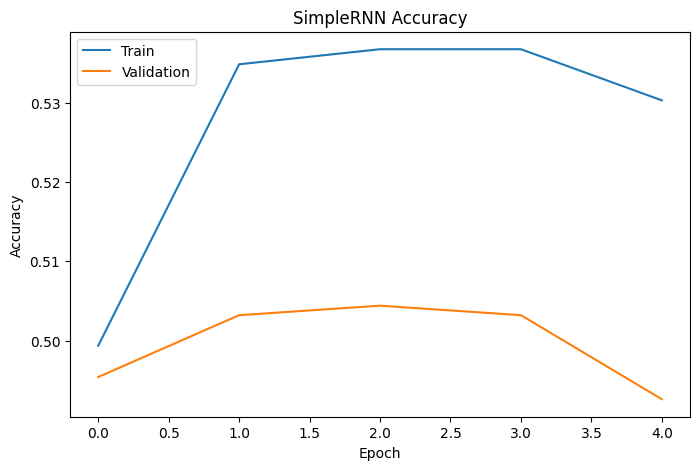

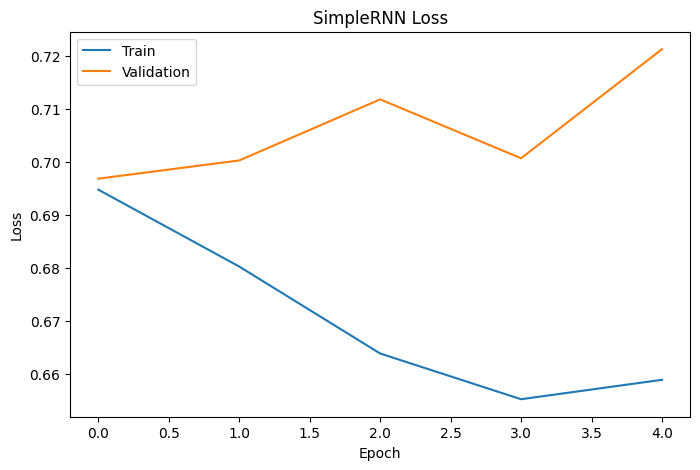

In [26]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history_rnn.history['accuracy'])
plt.plot(history_rnn.history['val_accuracy'])
plt.title('SimpleRNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history_rnn.history['loss'])
plt.plot(history_rnn.history['val_loss'])
plt.title('SimpleRNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.optimizers import Adam

# Parameters
VOCAB_SIZE = 10000
MAX_LEN = 250

# LSTM Model
lstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE,
              output_dim=128,
              input_length=MAX_LEN),

    LSTM(64),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

# Compile Model
lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Model Summary
lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
history_lstm = lstm_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.4972 - loss: 0.6954 - val_accuracy: 0.5122 - val_loss: 0.6929
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5239 - loss: 0.6789 - val_accuracy: 0.5250 - val_loss: 0.6847
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5403 - loss: 0.6545 - val_accuracy: 0.7472 - val_loss: 0.6703
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8089 - loss: 0.4599 - val_accuracy: 0.8630 - val_loss: 0.3477
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9073 - loss: 0.2445 - val_accuracy: 0.8746 - val_loss: 0.3278


In [29]:
loss_lstm, accuracy_lstm = lstm_model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print(f"Test Loss: {loss_lstm:.4f}")
print(f"Test Accuracy: {accuracy_lstm:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8671 - loss: 0.3404
Test Loss: 0.3404
Test Accuracy: 0.8671


In [30]:
sample_review = X_test_pad[0].reshape(1, -1)

prediction = lstm_model.predict(sample_review)

if prediction > 0.5:
    print("Positive Review 😊")
else:
    print("Negative Review 😞")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
Negative Review 😞


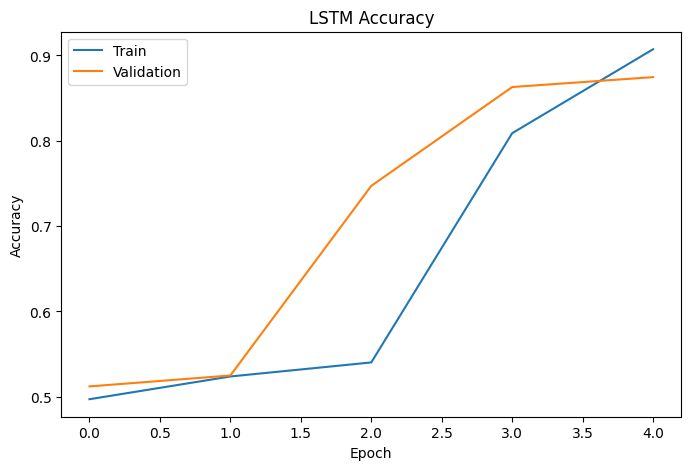

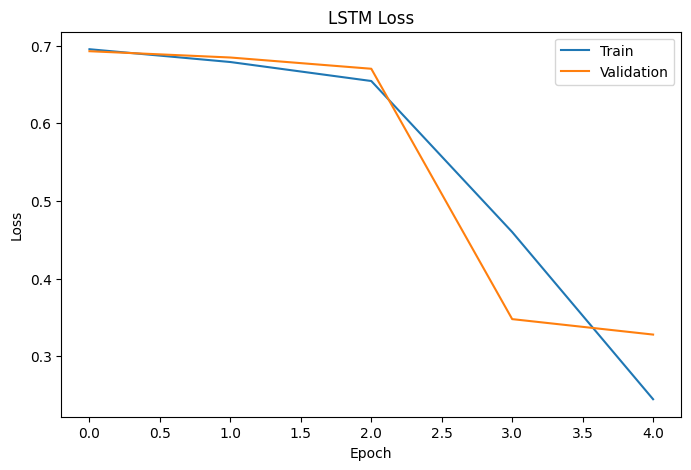

In [31]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure(figsize=(8,5))
plt.plot(history_lstm.history['accuracy'])
plt.plot(history_lstm.history['val_accuracy'])
plt.title('LSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss Plot
plt.figure(figsize=(8,5))
plt.plot(history_lstm.history['loss'])
plt.plot(history_lstm.history['val_loss'])
plt.title('LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense
from tensorflow.keras.optimizers import Adam

# Parameters
VOCAB_SIZE = 10000
MAX_LEN = 250

# GRU Model
gru_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE,
              output_dim=128,
              input_length=MAX_LEN),

    GRU(64),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

# Compile Model
gru_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display Model Summary
gru_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [33]:
history_gru = gru_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.5042 - loss: 0.6929 - val_accuracy: 0.5120 - val_loss: 0.6941
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.5610 - loss: 0.6721 - val_accuracy: 0.7108 - val_loss: 0.5771
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8389 - loss: 0.3829 - val_accuracy: 0.8566 - val_loss: 0.3466
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.9233 - loss: 0.2058 - val_accuracy: 0.8602 - val_loss: 0.3587
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9586 - loss: 0.1250 - val_accuracy: 0.8560 - val_loss: 0.4078


In [34]:
loss_gru, accuracy_gru = gru_model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print(f"Test Loss: {loss_gru:.4f}")
print(f"Test Accuracy: {accuracy_gru:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8476 - loss: 0.4323
Test Loss: 0.4323
Test Accuracy: 0.8476


In [35]:
sample_review = X_test_pad[0].reshape(1, -1)

prediction = gru_model.predict(sample_review)

if prediction > 0.5:
    print("Positive Review 😊")
else:
    print("Negative Review 😞")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
Negative Review 😞


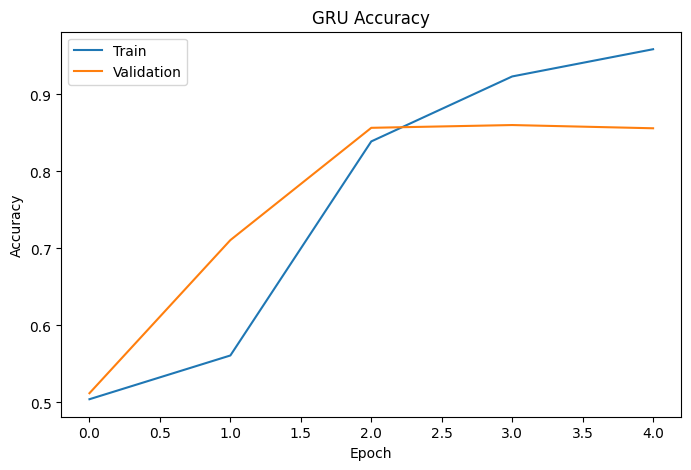

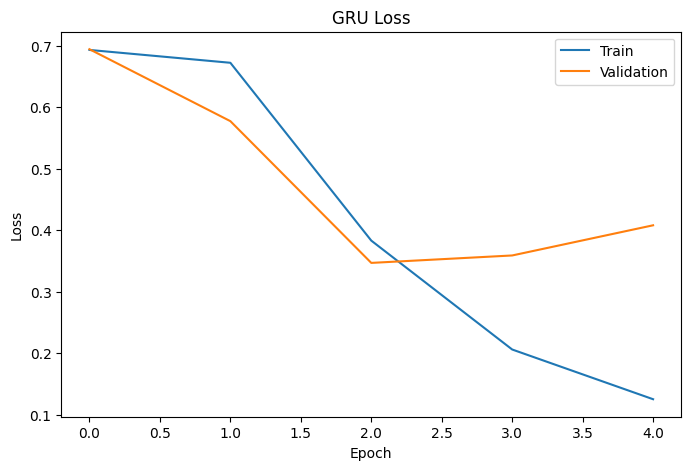

In [36]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure(figsize=(8,5))
plt.plot(history_gru.history['accuracy'])
plt.plot(history_gru.history['val_accuracy'])
plt.title('GRU Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss Plot
plt.figure(figsize=(8,5))
plt.plot(history_gru.history['loss'])
plt.plot(history_gru.history['val_loss'])
plt.title('GRU Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [37]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['SimpleRNN', 'LSTM', 'GRU'],
    'Test Accuracy': [
        accuracy_rnn,
        accuracy_lstm,
        accuracy_gru
    ]
})

print(comparison)

       Model  Test Accuracy
0  SimpleRNN        0.49900
1       LSTM        0.86712
2        GRU        0.84760


In [38]:
gru_model.save("gru_sentiment_model.h5")

In [39]:
lstm_model.save("lstm_sentiment_model.h5")

In [40]:
import time
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [41]:
# SimpleRNN
start = time.time()

history_rnn = simple_rnn_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

rnn_time = time.time() - start

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.5394 - loss: 0.6398 - val_accuracy: 0.5028 - val_loss: 0.7636
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.5452 - loss: 0.6380 - val_accuracy: 0.5028 - val_loss: 0.7600
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.5469 - loss: 0.6341 - val_accuracy: 0.5022 - val_loss: 0.7661
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.5511 - loss: 0.6315 - val_accuracy: 0.5032 - val_loss: 0.7845
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.5433 - loss: 0.6317 - val_accuracy: 0.5066 - val_loss: 0.7789


In [42]:
# LSTM
start = time.time()

history_lstm = lstm_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

lstm_time = time.time() - start

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9550 - loss: 0.1425 - val_accuracy: 0.8592 - val_loss: 0.3676
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9744 - loss: 0.0900 - val_accuracy: 0.8578 - val_loss: 0.4421
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9868 - loss: 0.0560 - val_accuracy: 0.8562 - val_loss: 0.4826
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9894 - loss: 0.0446 - val_accuracy: 0.8664 - val_loss: 0.5245
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9919 - loss: 0.0341 - val_accuracy: 0.8610 - val_loss: 0.5629


In [43]:
# GRU
start = time.time()

history_gru = gru_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

gru_time = time.time() - start

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9783 - loss: 0.0706 - val_accuracy: 0.8598 - val_loss: 0.4786
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9887 - loss: 0.0427 - val_accuracy: 0.8620 - val_loss: 0.5988
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9905 - loss: 0.0335 - val_accuracy: 0.8550 - val_loss: 0.5751
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9937 - loss: 0.0237 - val_accuracy: 0.8562 - val_loss: 0.7437
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9948 - loss: 0.0215 - val_accuracy: 0.8554 - val_loss: 0.6538


In [44]:
# SimpleRNN
y_pred_rnn = (simple_rnn_model.predict(X_test_pad) > 0.5).astype(int)

# LSTM
y_pred_lstm = (lstm_model.predict(X_test_pad) > 0.5).astype(int)

# GRU
y_pred_gru = (gru_model.predict(X_test_pad) > 0.5).astype(int)

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step


In [45]:
# SimpleRNN
acc_rnn = accuracy_score(y_test, y_pred_rnn)
prec_rnn = precision_score(y_test, y_pred_rnn)
rec_rnn = recall_score(y_test, y_pred_rnn)
f1_rnn = f1_score(y_test, y_pred_rnn)

# LSTM
acc_lstm = accuracy_score(y_test, y_pred_lstm)
prec_lstm = precision_score(y_test, y_pred_lstm)
rec_lstm = recall_score(y_test, y_pred_lstm)
f1_lstm = f1_score(y_test, y_pred_lstm)

# GRU
acc_gru = accuracy_score(y_test, y_pred_gru)
prec_gru = precision_score(y_test, y_pred_gru)
rec_gru = recall_score(y_test, y_pred_gru)
f1_gru = f1_score(y_test, y_pred_gru)

In [46]:
val_acc_rnn = history_rnn.history['val_accuracy'][-1]
val_loss_rnn = history_rnn.history['val_loss'][-1]

val_acc_lstm = history_lstm.history['val_accuracy'][-1]
val_loss_lstm = history_lstm.history['val_loss'][-1]

val_acc_gru = history_gru.history['val_accuracy'][-1]
val_loss_gru = history_gru.history['val_loss'][-1]

In [47]:
params_rnn = simple_rnn_model.count_params()
params_lstm = lstm_model.count_params()
params_gru = gru_model.count_params()

In [48]:
comparison_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Time (sec)",
        "Validation Accuracy",
        "Validation Loss",
        "Number of Parameters"
    ],

    "SimpleRNN": [
        acc_rnn,
        prec_rnn,
        rec_rnn,
        f1_rnn,
        rnn_time,
        val_acc_rnn,
        val_loss_rnn,
        params_rnn
    ],

    "LSTM": [
        acc_lstm,
        prec_lstm,
        rec_lstm,
        f1_lstm,
        lstm_time,
        val_acc_lstm,
        val_loss_lstm,
        params_lstm
    ],

    "GRU": [
        acc_gru,
        prec_gru,
        rec_gru,
        f1_gru,
        gru_time,
        val_acc_gru,
        val_loss_gru,
        params_gru
    ]
})

print(comparison_df)

                 Metric     SimpleRNN          LSTM           GRU
0              Accuracy  5.044400e-01  8.505200e-01  8.473600e-01
1             Precision  5.407190e-01  8.615397e-01  8.454256e-01
2                Recall  5.896000e-02  8.352800e-01  8.501600e-01
3              F1 Score  1.063262e-01  8.482067e-01  8.477862e-01
4   Training Time (sec)  4.403611e+01  2.590644e+01  2.668347e+01
5   Validation Accuracy  5.066000e-01  8.610000e-01  8.554000e-01
6       Validation Loss  7.789491e-01  5.628866e-01  6.537730e-01
7  Number of Parameters  1.294465e+06  1.331521e+06  1.319361e+06


In [49]:
gru_model.save("best_sentiment_model.h5")

In [50]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

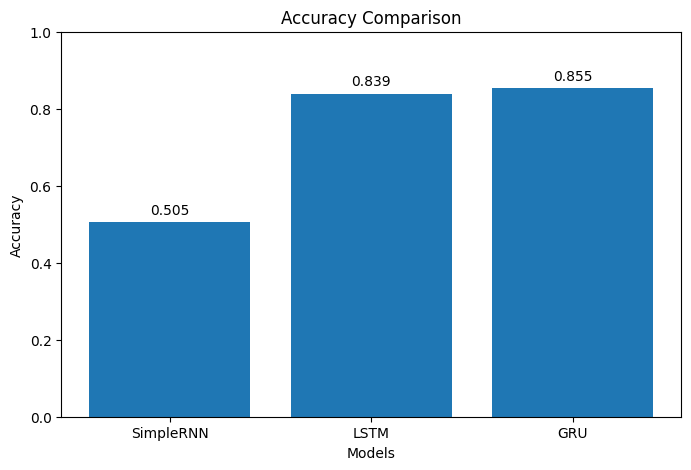

In [51]:
import matplotlib.pyplot as plt

models = ['SimpleRNN', 'LSTM', 'GRU']
accuracies = [0.5048, 0.8394, 0.8546]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)

plt.title('Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.ylim(0,1)

for i, v in enumerate(accuracies):
    plt.text(i, v+0.02, f'{v:.3f}', ha='center')

plt.show()

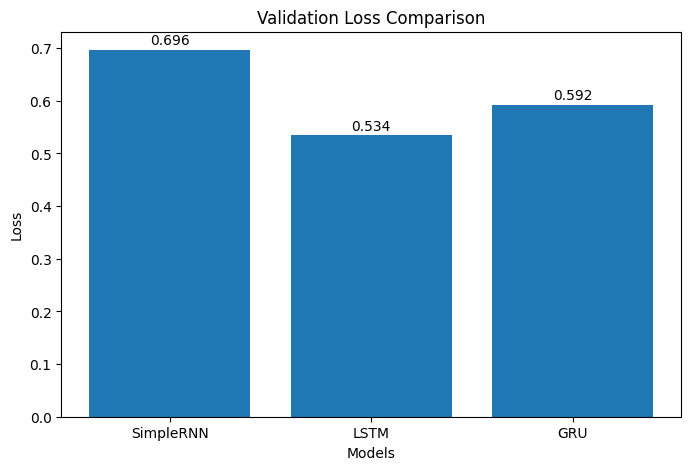

In [52]:
import matplotlib.pyplot as plt
import numpy as np

models = ['SimpleRNN', 'LSTM', 'GRU']

validation_loss = [
    0.6963,
    0.5343,
    0.5922
]

plt.figure(figsize=(8,5))

plt.bar(models, validation_loss)

plt.title('Validation Loss Comparison')
plt.xlabel('Models')
plt.ylabel('Loss')

for i, v in enumerate(validation_loss):
    plt.text(i, v+0.01, f'{v:.3f}', ha='center')

plt.show()

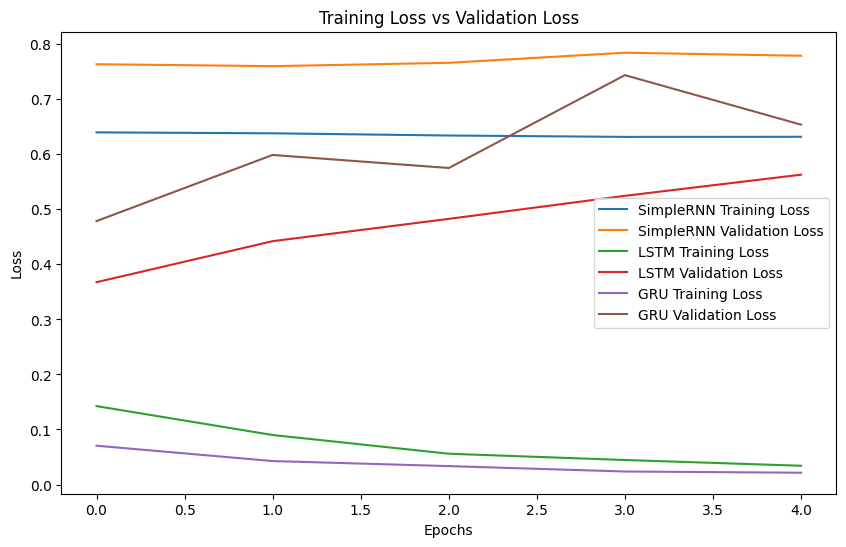

In [53]:
plt.figure(figsize=(10,6))

plt.plot(history_rnn.history['loss'],
         label='SimpleRNN Training Loss')

plt.plot(history_rnn.history['val_loss'],
         label='SimpleRNN Validation Loss')

plt.plot(history_lstm.history['loss'],
         label='LSTM Training Loss')

plt.plot(history_lstm.history['val_loss'],
         label='LSTM Validation Loss')

plt.plot(history_gru.history['loss'],
         label='GRU Training Loss')

plt.plot(history_gru.history['val_loss'],
         label='GRU Validation Loss')

plt.title('Training Loss vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

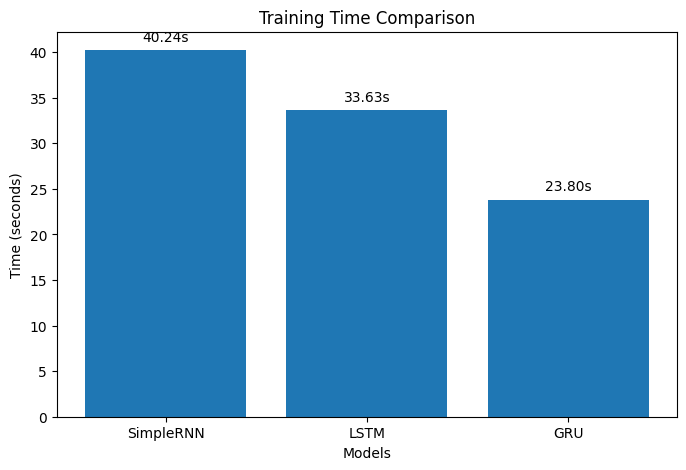

In [54]:
import matplotlib.pyplot as plt

models = ['SimpleRNN', 'LSTM', 'GRU']

training_time = [
    40.24,
    33.63,
    23.80
]

plt.figure(figsize=(8,5))

plt.bar(models, training_time)

plt.title('Training Time Comparison')
plt.xlabel('Models')
plt.ylabel('Time (seconds)')

for i, v in enumerate(training_time):
    plt.text(i, v+1, f'{v:.2f}s', ha='center')

plt.show()

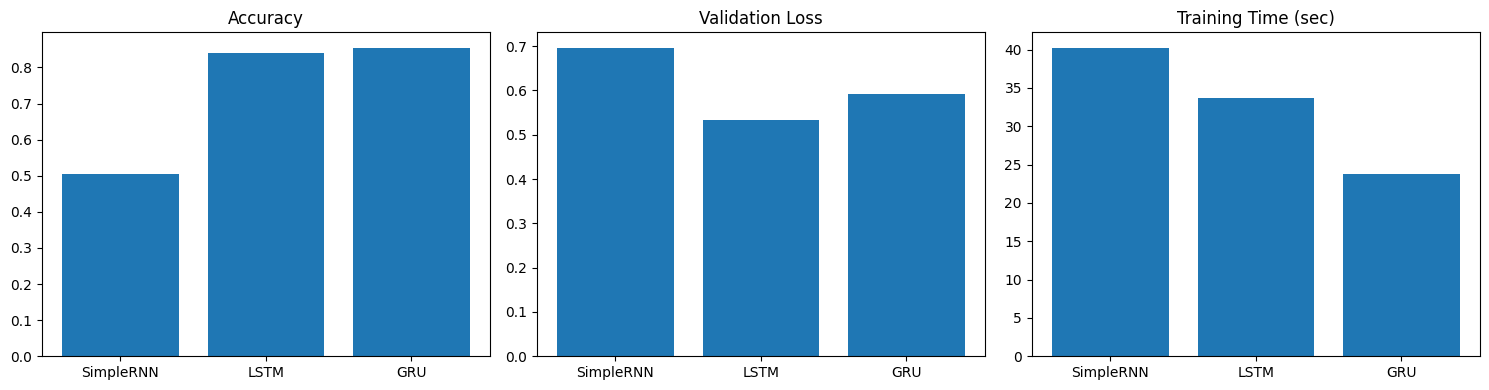

In [55]:
import matplotlib.pyplot as plt

models = ['SimpleRNN', 'LSTM', 'GRU']

accuracy = [0.5048, 0.8394, 0.8546]
val_loss = [0.6963, 0.5343, 0.5922]
training_time = [40.24, 33.63, 23.80]

plt.figure(figsize=(15,4))

# Accuracy
plt.subplot(1,3,1)
plt.bar(models, accuracy)
plt.title('Accuracy')

# Validation Loss
plt.subplot(1,3,2)
plt.bar(models, val_loss)
plt.title('Validation Loss')

# Training Time
plt.subplot(1,3,3)
plt.bar(models, training_time)
plt.title('Training Time (sec)')

plt.tight_layout()
plt.show()

In [56]:
custom_reviews = [
    "This movie was absolutely fantastic and I enjoyed every minute.",
    "The movie was boring and a complete waste of time.",
    "The acting was good but the story was average."
]

In [57]:
import re
import string
from tensorflow.keras.preprocessing.sequence import pad_sequences

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )
    return text

processed_reviews = [
    preprocess_text(review)
    for review in custom_reviews
]

sequences = tokenizer.texts_to_sequences(
    processed_reviews
)

padded_reviews = pad_sequences(
    sequences,
    maxlen=250,
    padding='post',
    truncating='post'
)

In [58]:
def predict_sentiment(model, review):

    prediction = model.predict(review, verbose=0)[0][0]

    sentiment = (
        "Positive 😊"
        if prediction >= 0.5
        else "Negative 😞"
    )

    confidence = (
        prediction * 100
        if prediction >= 0.5
        else (1 - prediction) * 100
    )

    return sentiment, confidence

In [59]:
for i, review in enumerate(padded_reviews):

    print("\n" + "="*60)
    print(f"Review {i+1}")
    print(custom_reviews[i])

    # SimpleRNN
    sentiment, confidence = predict_sentiment(
        simple_rnn_model,
        review.reshape(1, -1)
    )

    print("\nSimpleRNN")
    print("Sentiment:", sentiment)
    print(f"Confidence: {confidence:.2f}%")

    # LSTM
    sentiment, confidence = predict_sentiment(
        lstm_model,
        review.reshape(1, -1)
    )

    print("\nLSTM")
    print("Sentiment:", sentiment)
    print(f"Confidence: {confidence:.2f}%")

    # GRU
    sentiment, confidence = predict_sentiment(
        gru_model,
        review.reshape(1, -1)
    )

    print("\nGRU")
    print("Sentiment:", sentiment)
    print(f"Confidence: {confidence:.2f}%")


Review 1
This movie was absolutely fantastic and I enjoyed every minute.

SimpleRNN
Sentiment: Negative 😞
Confidence: 51.98%

LSTM
Sentiment: Positive 😊
Confidence: 99.44%

GRU
Sentiment: Positive 😊
Confidence: 99.75%

Review 2
The movie was boring and a complete waste of time.

SimpleRNN
Sentiment: Negative 😞
Confidence: 51.98%

LSTM
Sentiment: Negative 😞
Confidence: 99.65%

GRU
Sentiment: Negative 😞
Confidence: 99.96%

Review 3
The acting was good but the story was average.

SimpleRNN
Sentiment: Negative 😞
Confidence: 51.98%

LSTM
Sentiment: Positive 😊
Confidence: 98.04%

GRU
Sentiment: Positive 😊
Confidence: 95.67%


In [60]:
import pandas as pd

results = []

for i, review in enumerate(padded_reviews):

    for model_name, model in [
        ("SimpleRNN", simple_rnn_model),
        ("LSTM", lstm_model),
        ("GRU", gru_model)
    ]:

        prediction = model.predict(
            review.reshape(1, -1),
            verbose=0
        )[0][0]

        sentiment = (
            "Positive"
            if prediction >= 0.5
            else "Negative"
        )

        confidence = (
            prediction * 100
            if prediction >= 0.5
            else (1 - prediction) * 100
        )

        results.append([
            f"Review {i+1}",
            model_name,
            sentiment,
            round(confidence, 2)
        ])

df_results = pd.DataFrame(
    results,
    columns=[
        "Review",
        "Model",
        "Predicted Sentiment",
        "Confidence (%)"
    ]
)

print(df_results)

     Review      Model Predicted Sentiment  Confidence (%)
0  Review 1  SimpleRNN            Negative       51.980000
1  Review 1       LSTM            Positive       99.440002
2  Review 1        GRU            Positive       99.750000
3  Review 2  SimpleRNN            Negative       51.980000
4  Review 2       LSTM            Negative       99.650002
5  Review 2        GRU            Negative       99.959999
6  Review 3  SimpleRNN            Negative       51.980000
7  Review 3       LSTM            Positive       98.040001
8  Review 3        GRU            Positive       95.669998


In [60]:
simple_rnn_model = load_model("simple_rnn_model.h5")
lstm_model = load_model("lstm_model.h5")
gru_model = load_model("gru_model.h5")

with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

In [61]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [64]:
import os

for file in os.listdir():
    print(file)

.config
gru_sentiment_model.h5
best_sentiment_model.h5
streamlit_files.zip
tokenizer.pkl
lstm_sentiment_model.h5
sample_data


In [65]:
simple_rnn_model.save("simple_rnn_model.h5")
lstm_model.save("lstm_model.h5")
gru_model.save("gru_model.h5")